|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 8:</h2>|<h1>The Capstone<h1>|
|<h2>Section:</h2>|<h1>One engine<h1>|
|<h2>Lecture:</h2>|<h1><b>One rule: pending tokens and a budget<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')


# One rule for the whole scheduler

Stage 10 had a scheduler with preemption. Stage 11 had a different scheduler
with a token budget. A real engine cannot have two. It needs one rule that
covers a decode, a prefill, a chunked prefill and a preempted sequence.

The rule: a sequence has PENDING tokens. Those are the token ids whose K and V
are not in the cache yet.

- A decode has one pending token.
- A new request has its whole prompt pending.
- A preempted sequence has everything pending again: its prompt and its
  output.

Each step gives pending tokens to sequences until the token budget runs out.
That is all. vLLM V1 schedules like this.

In [2]:
from collections import deque
from dataclasses import dataclass

@dataclass(eq=False)
class Sequence:
    prompt_len: int
    max_tokens: int
    computed: int = 0       # tokens whose KV is in the cache
    generated: int = 0      # output tokens so far
    blocks: int = 0

    def pending(self):
        """The tokens that the model must still process."""
        return self.prompt_len + self.generated - self.computed

class TokenCounter:
    """The pending-token scheduler with no model. It counts tokens and blocks."""
    def __init__(self, pool_blocks, budget, block_size=16, max_seqs=64):
        self.pool_blocks = pool_blocks
        self.budget = budget
        self.block_size = block_size
        self.max_seqs = max_seqs
        self.free = pool_blocks
        self.waiting = deque()
        self.running = []

    def blocks_needed(self, seq, num_tokens):
        return -(-(seq.computed + num_tokens) // self.block_size) - seq.blocks

    def _compute(self, seq, num_tokens):
        new_blocks = self.blocks_needed(seq, num_tokens)
        self.free -= new_blocks
        seq.blocks += new_blocks
        seq.computed += num_tokens

    def _preempt_newest(self):
        victim = self.running.pop()
        self.free += victim.blocks
        victim.blocks = 0
        victim.computed = 0
        self.waiting.appendleft(victim)
        return victim

    def _schedule_running(self, budget_left):
        """-> (decode tokens, prefill tokens, preemptions, budget left)."""
        decode = prefill = preemptions = 0
        index = 0
        while index < len(self.running) and budget_left > 0:
            seq = self.running[index]
            num_tokens = min(seq.pending(), budget_left)
            while self.blocks_needed(seq, num_tokens) > self.free:
                preemptions += 1
                if self._preempt_newest() is seq:
                    break
            if seq not in self.running:
                continue
            self._compute(seq, num_tokens)
            budget_left -= num_tokens
            if num_tokens == 1 and seq.computed > seq.prompt_len:
                decode += 1
            else:
                prefill += num_tokens
            index += 1
        return decode, prefill, preemptions, budget_left

    def _admit_waiting(self, budget_left):
        """Admit in arrival order while the budget and the pool allow.
        -> the prefill tokens."""
        prefill = 0
        while self.waiting and budget_left > 0 and len(self.running) < self.max_seqs:
            seq = self.waiting[0]
            num_tokens = min(seq.pending(), budget_left)
            if self.blocks_needed(seq, num_tokens) > self.free:
                break
            self.running.append(self.waiting.popleft())
            self._compute(seq, num_tokens)
            budget_left -= num_tokens
            prefill += num_tokens
        return prefill

    def _finish_step(self):
        """Each sequence with no pending tokens gets its next token."""
        for seq in list(self.running):
            if seq.pending() == 0:
                seq.generated += 1
                if seq.generated >= seq.max_tokens:
                    self.running.remove(seq)
                    self.free += seq.blocks
                    seq.blocks = 0

    def step(self):
        """-> the decode tokens, prefill tokens, preemptions and blocks in use."""
        decode, prefill, preemptions, budget_left = self._schedule_running(self.budget)
        if not preemptions:
            prefill += self._admit_waiting(budget_left)
        self._finish_step()
        return {'decode': decode, 'prefill': prefill, 'preemptions': preemptions,
                'used': self.pool_blocks - self.free}

def simulate(pool_blocks, budget, arrivals, prompt_lens, output_lens):
    """Run the scheduler until all requests finish. -> one dict for each step."""
    engine = TokenCounter(pool_blocks, budget)
    steps, next_arrival = [], 0
    while next_arrival < len(arrivals) or engine.waiting or engine.running:
        while next_arrival < len(arrivals) and arrivals[next_arrival] <= len(steps):
            engine.waiting.append(Sequence(prompt_lens[next_arrival],
                                           output_lens[next_arrival]))
            next_arrival += 1
        steps.append(engine.step())
    return steps

### Run it on a load that arrives over time

Requests arrive for 200 steps. Prompts are 64 to 1024 tokens, and outputs are
16 to 256 tokens. The pool is large enough, so the scheduler preempts nothing.

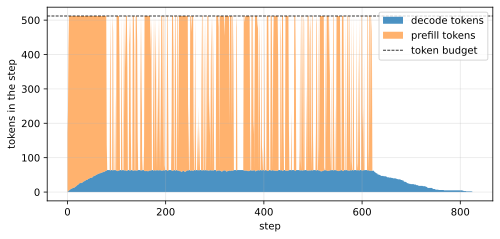

826 steps. 37% of them use the whole budget.
decode tokens: 41,238   prefill tokens: 166,852


In [3]:
rng = np.random.default_rng(0)
NUM_REQUESTS = 300
BUDGET = 512
arrivals = np.sort(rng.integers(0, 200, NUM_REQUESTS))
prompt_lens = rng.integers(64, 1024, NUM_REQUESTS)
output_lens = rng.integers(16, 256, NUM_REQUESTS)
steps = simulate(pool_blocks=20000, budget=BUDGET, arrivals=arrivals,
                 prompt_lens=prompt_lens, output_lens=output_lens)
decode = np.array([step['decode'] for step in steps])
prefill = np.array([step['prefill'] for step in steps])
fig, axis = plt.subplots(figsize=(8, 3.5))
step_numbers = np.arange(len(steps))
axis.fill_between(step_numbers, 0, decode, label='decode tokens', alpha=.8)
axis.fill_between(step_numbers, decode, decode + prefill, label='prefill tokens', alpha=.6)
axis.axhline(BUDGET, color='k', lw=.8, ls='--', label='token budget')
axis.set(xlabel='step', ylabel='tokens in the step')
axis.legend(loc='upper right')
axis.grid(alpha=.3)
plt.show()
full_steps = np.mean((decode + prefill) >= BUDGET)
print(f'{len(steps)} steps. {100*full_steps:.0f}% of them use the whole budget.')
print(f'decode tokens: {decode.sum():,}   prefill tokens: {prefill.sum():,}')

### What the picture shows

At the start, while prompts wait, the steps are full. The decodes take their
one token each first, and the prefill chunks fill the rest of the budget. No
step waits for a long prompt, because a long prompt simply takes several
steps.

After the last prompt, the prefill band disappears. The rest of the run
is the tail of the decodes, and those steps are far below the budget. That is
why only part of the steps is full.

The same rule makes both regimes. Nothing in the code says "prefill step" or
"decode step".

### Now make the pool too small

Cut the pool until the running sequences outgrow it. The same rule now
preempts. It frees the newest sequence, and it puts that sequence back at the
front of the queue, with all of its tokens pending again.

In [4]:
useful_work = int(prompt_lens.sum() + output_lens.sum())
rows = []
for pool_blocks in (20000, 4000, 2000, 1200):
    steps = simulate(pool_blocks=pool_blocks, budget=BUDGET, arrivals=arrivals,
                     prompt_lens=prompt_lens, output_lens=output_lens)
    work = sum(step['decode'] + step['prefill'] for step in steps)
    preemptions = sum(step['preemptions'] for step in steps)
    rows.append((pool_blocks, len(steps), preemptions, work / useful_work))
print(f'{"pool":>6} {"steps":>6} {"preemptions":>12} {"work / useful work":>20}')
for pool_blocks, num_steps, preemptions, work_ratio in rows:
    print(f'{pool_blocks:>6} {num_steps:>6} {preemptions:>12} {work_ratio:>20.2f}')

  pool  steps  preemptions   work / useful work
 20000    826            0                 1.00
  4000    826            0                 1.00
  2000   1014          150                 1.31
  1200   1567          221                 1.45


### Read the last column

"Work / useful work" is the number of tokens that the engine computed,
divided by the tokens that it had to compute. With a large pool it is 1.00.
Each preemption adds the work of the victim again, because a recompute feeds
all of its tokens a second time.

This is the price of preemption by recompute, as a ratio. It does not depend
on the card. The capstone engine uses exactly this rule, and its checks prove
that a preemption changes no output token.

    ./vc guide 22